In [135]:
from sqlalchemy import create_engine
import pandas as pd
import os
from sshtunnel import SSHTunnelForwarder
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import re

from sshtunnel import SSHTunnelForwarder
import socket
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

In [48]:
plt.rcParams['font.family'] = 'Century Gothic'

In [29]:


SSH_HOST = "3.139.164.72"
SSH_PORT = 22
SSH_USER = "dclaudiopacheco"
SSH_KEY_PATH = r"I:\Mi unidad\credenciales\dclaudiopacheco.pem"
SSH_KEY_PASSPHRASE = "+THB2JaMpy5/Ma0V7yiQn*MfHMuSw9EsEL3kgR56"

REMOTE_DB_HOST = "agdatabases.cu1njaiwfxac.us-east-2.rds.amazonaws.com"
REMOTE_DB_PORT = 3306

tunnel = SSHTunnelForwarder(
    (SSH_HOST, SSH_PORT),
    ssh_username=SSH_USER,
    ssh_pkey=SSH_KEY_PATH,
    ssh_private_key_password=SSH_KEY_PASSPHRASE,
    remote_bind_address=(REMOTE_DB_HOST, REMOTE_DB_PORT),
    local_bind_address=("127.0.0.1", 0)
)

tunnel.start()

print("Puerto local:", tunnel.local_bind_port)

# Ahora probamos si realmente responde el puerto
sock = socket.socket()
result = sock.connect_ex(("127.0.0.1", tunnel.local_bind_port))

if result == 0:
    print("✅ El túnel sí conecta al RDS")
else:
    print("❌ El túnel NO conecta al RDS")

sock.close()

Puerto local: 56402
✅ El túnel sí conecta al RDS


In [30]:
from sqlalchemy import create_engine, text

DB_USER = "dclaudiopacheco"
DB_PASS = "BgDR5BA7UUj7zIJuLUSr3SzKRkT28N1r1nLeEqsV"
DB_NAME = "ciencia_datos"

DATABASE_URL = (
    f"mysql+pymysql://{DB_USER}:{DB_PASS}"
    f"@127.0.0.1:{tunnel.local_bind_port}/{DB_NAME}"
)

engine = create_engine(DATABASE_URL)

with engine.connect() as conn:
    print("✅ MySQL responde:", conn.execute(text("SELECT 1")).scalar())

✅ MySQL responde: 1


In [113]:
def ejecutar_sps(engine, sps_dict):
    resultados = {}
    
    for nombre, sp in sps_dict.items():
        query = f"CALL {sp}()"
        df = pd.read_sql(query, engine)
        print(f"{nombre}: {len(df)} registros")
        resultados[nombre] = df
        
    return resultados



def barplot_ordenado(data, x, y, etiqueta_formato=None, color="#0033A0"):
    
    # Ordenar por variable del eje x
    data = data.sort_values(x, ascending=False)
    
    ax = sns.barplot(
        data=data,
        x=x,
        y=y,
        color=color
    )
    
    # Agregar etiquetas
    for i, v in enumerate(data[x]):
        
        if etiqueta_formato:
            texto = etiqueta_formato(v)
        else:
            texto = f"{v}"
        
        ax.text(
            v,
            i,
            f"{v:.1f}%",
            va="center",
            ha="left",
            fontsize=10
        )
    
    return ax

In [32]:
stored_procedures = {
    "abandono": "ciencia_datos.sp_tasa_abandono",
    "retencion": "ciencia_datos.sp_tasa_retencion",
    "fragilidad": "ciencia_datos.sp_tasa_fragilidad_inicial_abandono_temprano",
    "bajas_sn_cargas": "ciencia_datos.sp_bajas_alumnos_sn_cargas"
}

resultados = ejecutar_sps(engine, stored_procedures)

abandono: 24367 registros
retencion: 1932 registros
fragilidad: 7344 registros
bajas_sn_cargas: 13500 registros


In [33]:
# Tablas
abandono = resultados["abandono"]
retencion = resultados["retencion"]
fragilidad = resultados["fragilidad"]
bajas_sn_cargas = resultados["bajas_sn_cargas"]

In [80]:
retencion

,anio,fecha_registro,categoria,id_plan_estudio,programa,id_corporacion,corporacion,id_alumno,id_moodle,estatus_casa,motivo,intervencion,retencion
0,2024,2024-12-16,Licenciatura,62,LEG COPPEL,2,COPPEL,179557,48182,SUSPENDIDOS POR INACTIVIDAD,Retención,1,SI
1,2024,2024-12-16,Licenciatura,62,LEG COPPEL,2,COPPEL,118034,11606,SUSPENDIDOS POR INACTIVIDAD,Retención,1,NO
2,2024,2024-12-16,Preparatoria,47,PREPA COPPEL,2,COPPEL,117574,11530,BAJA DE LA EMPRESA,Retención,1,NO
3,2024,2024-12-16,Maestría,50,MDN Coppel,2,COPPEL,151840,28133,SUSPENDIDO POR CAMBIO DE GENERACION,Retención,1,SI
4,2024,2024-12-16,Maestría,50,MDN Coppel,2,COPPEL,151916,28209,BAJA DEL PROGRAMA,Retención,1,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1927,2026,2026-02-17,Licenciatura,62,LEG COPPEL,2,COPPEL,200703,57649,None,Retención,0,Pendiente
1928,2026,2026-02-18,Ingeniería,18,IDS Coppel,2,COPPEL,197747,56234,None,Retención,0,Pendiente
1929,2026,2026-02-18,Ingeniería,59,IDS UMI,6,UNIVERSIDAD MEXICO INTERNACIONAL,197632,56194,None,Retención,0,Pendiente
1930,2026,2026-02-19,Licenciatura,62,LEG COPPEL,2,COPPEL,200824,57751,None,Retención,0,Pendiente


#### Intervención

In [89]:
##Calcular tasa de abandono por año
intervencion_gral = (
    retencion
    .groupby("anio")
    .agg(
        total_registros=("id_alumno", "count"),
        total_bajas=("intervencion", "sum")
    )
    .reset_index()
)

# Calcular tasa de abandono
intervencion_gral["tasa_intervencion"] = (
    intervencion_gral["total_bajas"] / intervencion_gral["total_registros"]*100
)

intervencion_gral

,anio,total_registros,total_bajas,tasa_intervencion
0,2024,42,31,73.809524
1,2025,1694,1066,62.927981
2,2026,196,100,51.020408


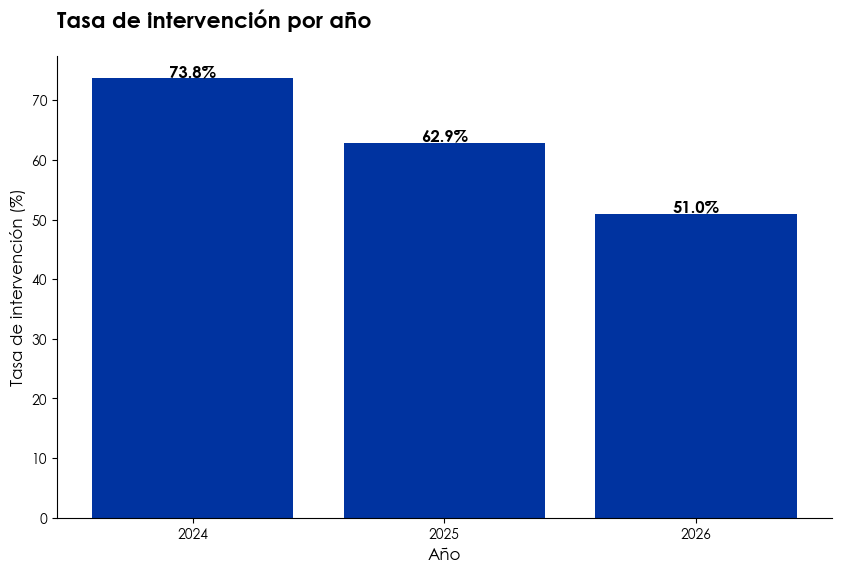

In [121]:
# Grafico de barras
plt.figure(figsize=(10, 6))
plt.bar(intervencion_gral["anio"], intervencion_gral["tasa_intervencion"], color="#0033A0")
plt.title("Tasa de intervención por año", fontsize=16, pad=20, color="black", fontweight="bold", loc="left")
plt.xlabel("Año", fontsize=12)
plt.ylabel("Tasa de intervención (%)", fontsize=12)
#Añadir etiquetas de porcentaje encima de cada barra
for index, row in intervencion_gral.iterrows():
    plt.text(row["anio"], row["tasa_intervencion"] + 0.2,
              f"{row['tasa_intervencion']:.1f}%", ha='center', fontsize=12, color="black", fontweight="bold")

plt.xticks(intervencion_gral["anio"])
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()


In [116]:
# Intervención por corporación
interv_corp = (
    retencion
    .groupby(["anio", "corporacion"])
    .agg(
        total_registros=("id_alumno", "count"),
        total_interv=("intervencion", "sum")
    )
    .reset_index()
)
interv_corp["tasa_intervencion"] = (
    interv_corp["total_interv"] / interv_corp["total_registros"]*
    100
)
interv_corp

,anio,corporacion,total_registros,total_interv,tasa_intervencion
0,2024,AG COLLEGE,2,2,100.000000
1,2024,ALPURA,1,1,100.000000
2,2024,CASA LEY,1,0,0.000000
3,2024,COPPEL,38,28,73.684211
4,2025,AG COLLEGE,140,82,58.571429
5,2025,AG SOCIAL,2,1,50.000000
6,2025,ALPURA,43,27,62.790698
7,2025,BAYER,10,8,80.000000
8,2025,CASA LEY,96,68,70.833333
9,2025,COPPEL,1318,833,63.201821


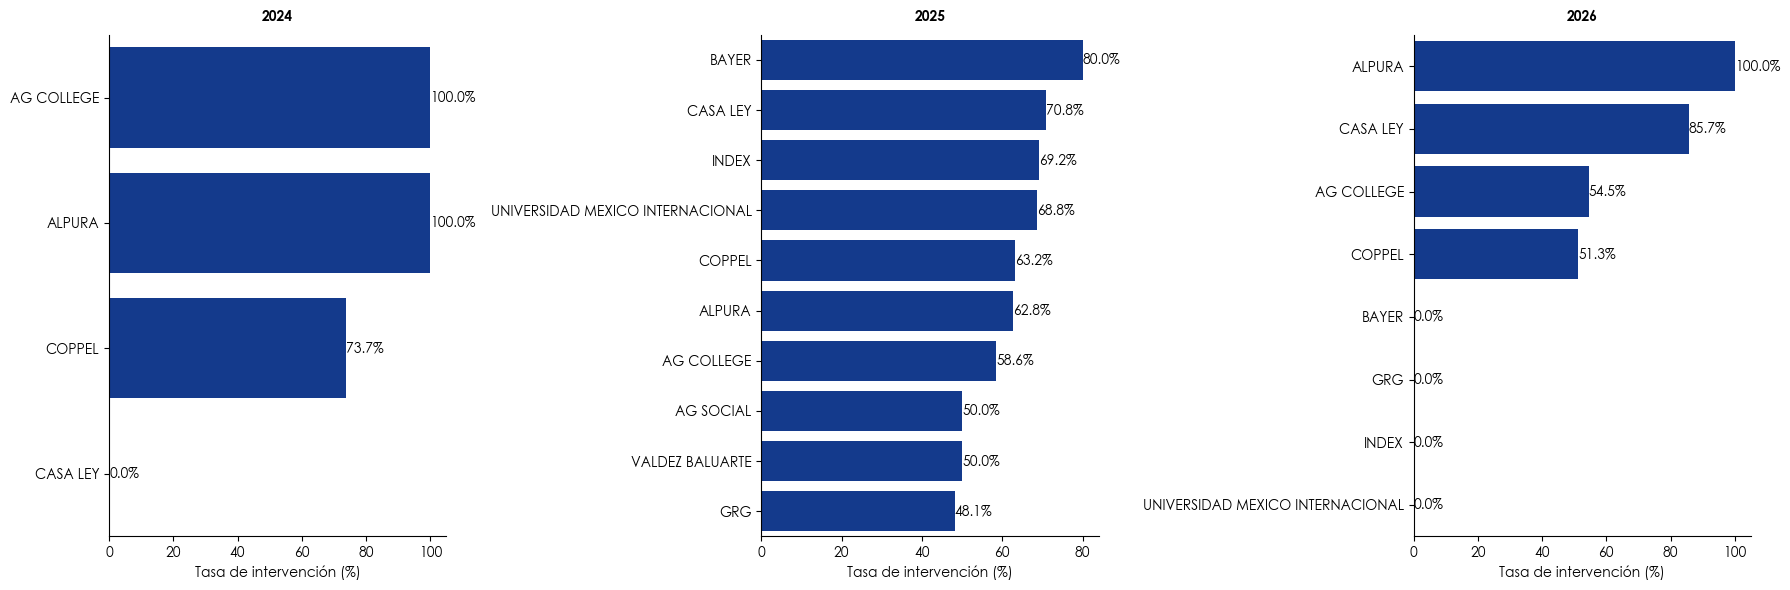

In [114]:
# Copia y ordena dentro de cada año
df_plot = interv_corp.copy()
# Crear facets
g = sns.FacetGrid(
    df_plot,
    col="anio",
    sharex=False,   # puedes poner True si quieres mismo eje X
    sharey=False,
    height=6,
    aspect=1
)

g.map_dataframe(barplot_ordenado, x="tasa_intervencion", y="corporacion", color="#0033A0")

# Títulos y estilo
g.set_titles("{col_name}", fontsize=20, fontweight="bold", color="black", pad=10)
g.set_axis_labels("Tasa de intervención (%)", "")

for ax in g.axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [118]:
#Intervención por programa
interv_prog = (
    retencion
    .groupby(["anio", "programa"])
    .agg(
        total_registros=("id_alumno", "count"),
        total_interv=("intervencion", "sum")
    )
    .reset_index()
)
interv_prog["tasa_interv"] = (
    interv_prog["total_interv"] / interv_prog["total_registros"]*
    100
)
interv_prog

,anio,programa,total_registros,total_interv,tasa_interv
0,2024,IDS Coppel,10,5,50.000000
1,2024,LDG AG LIC,2,2,100.000000
2,2024,LDG Ley,1,0,0.000000
3,2024,LEG COPPEL,18,14,77.777778
4,2024,MDN Coppel,4,4,100.000000
5,2024,PREPA COPPEL,6,5,83.333333
6,2024,Prepa alpura,1,1,100.000000
7,2025,ADMISIONES IDS COPPEL,1,0,0.000000
8,2025,BACHILLERATO FALCO ELECTRONICS,1,0,0.000000
9,2025,BACHILLERATO INDEX,9,6,66.666667


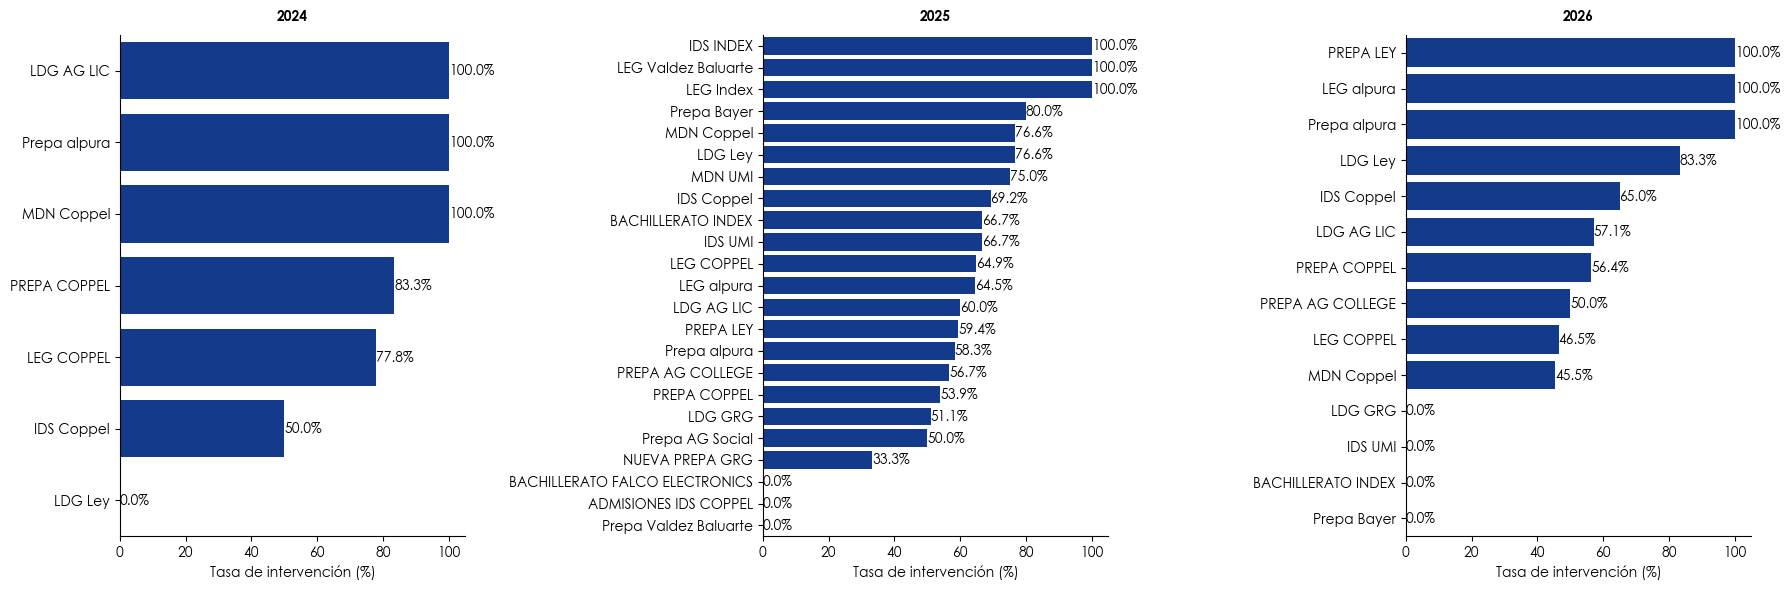

In [120]:
# Copia y ordena dentro de cada año
df_plot = interv_prog.copy()
# Crear facets
g = sns.FacetGrid(
    df_plot,
    col="anio",
    sharex=False,   # puedes poner True si quieres mismo eje X
    sharey=False,
    height=6,
    aspect=1
)

g.map_dataframe(barplot_ordenado, x="tasa_interv", y="programa", color="#0033A0")

# Títulos y estilo
g.set_titles("{col_name}", fontsize=20, fontweight="bold", color="black", pad=10)
g.set_axis_labels("Tasa de intervención (%)", "")

for ax in g.axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Retención

In [126]:
retencion_gral = (
    retencion
    .groupby("anio")
    .agg(
        total_registros=("id_alumno", "count"),
        total_retencion=("retencion", lambda x: (x == "SI").sum())
    )
    .reset_index()
)

retencion_gral["tasa_retencion"] = (
    retencion_gral["total_retencion"] /
    retencion_gral["total_registros"] * 100
).round(2)

retencion_gral

,anio,total_registros,total_retencion,tasa_retencion
0,2024,42,9,21.43
1,2025,1694,305,18.00
2,2026,196,25,12.76


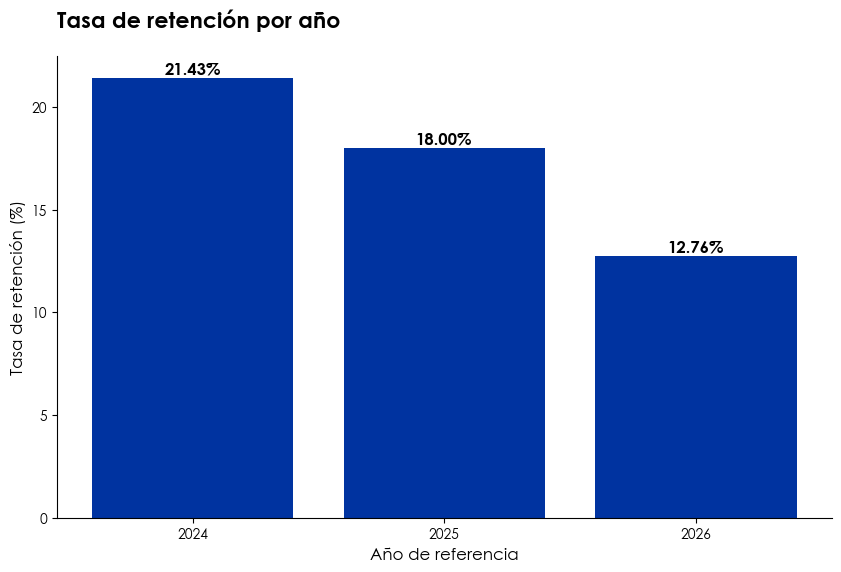

In [127]:
# Grafico de barras
plt.figure(figsize=(10, 6))
plt.bar(retencion_gral["anio"], retencion_gral["tasa_retencion"], color="#0033A0")
plt.title("Tasa de retención por año", fontsize=16, pad=20, color="black", fontweight="bold", loc="left")
plt.xlabel("Año de referencia", fontsize=12)
plt.ylabel("Tasa de retención (%)", fontsize=12)
#Añadir etiquetas de porcentaje encima de cada barra
for index, row in retencion_gral.iterrows():
    plt.text(row["anio"], row["tasa_retencion"] + 0.2,
              f"{row['tasa_retencion']:.2f}%", ha='center', fontsize=12, color="black", fontweight="bold")

plt.xticks(retencion_gral["anio"])
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()

In [128]:
##Retención por corporación

retencion_corp = (
    retencion
    .groupby(["anio", "corporacion"])
    .agg(
        total_registros=("id_alumno", "count"),
        total_retencion=("retencion", lambda x: (x == "SI").sum())
    )
    .reset_index()
)
retencion_corp["tasa_retencion"] = (
    retencion_corp["total_retencion"] /
    retencion_corp["total_registros"] * 100
).round(2)
retencion_corp


,anio,corporacion,total_registros,total_retencion,tasa_retencion
0,2024,AG COLLEGE,2,0,0.00
1,2024,ALPURA,1,1,100.00
2,2024,CASA LEY,1,0,0.00
3,2024,COPPEL,38,8,21.05
4,2025,AG COLLEGE,140,24,17.14
5,2025,AG SOCIAL,2,1,50.00
6,2025,ALPURA,43,8,18.60
7,2025,BAYER,10,1,10.00
8,2025,CASA LEY,96,29,30.21
9,2025,COPPEL,1318,230,17.45


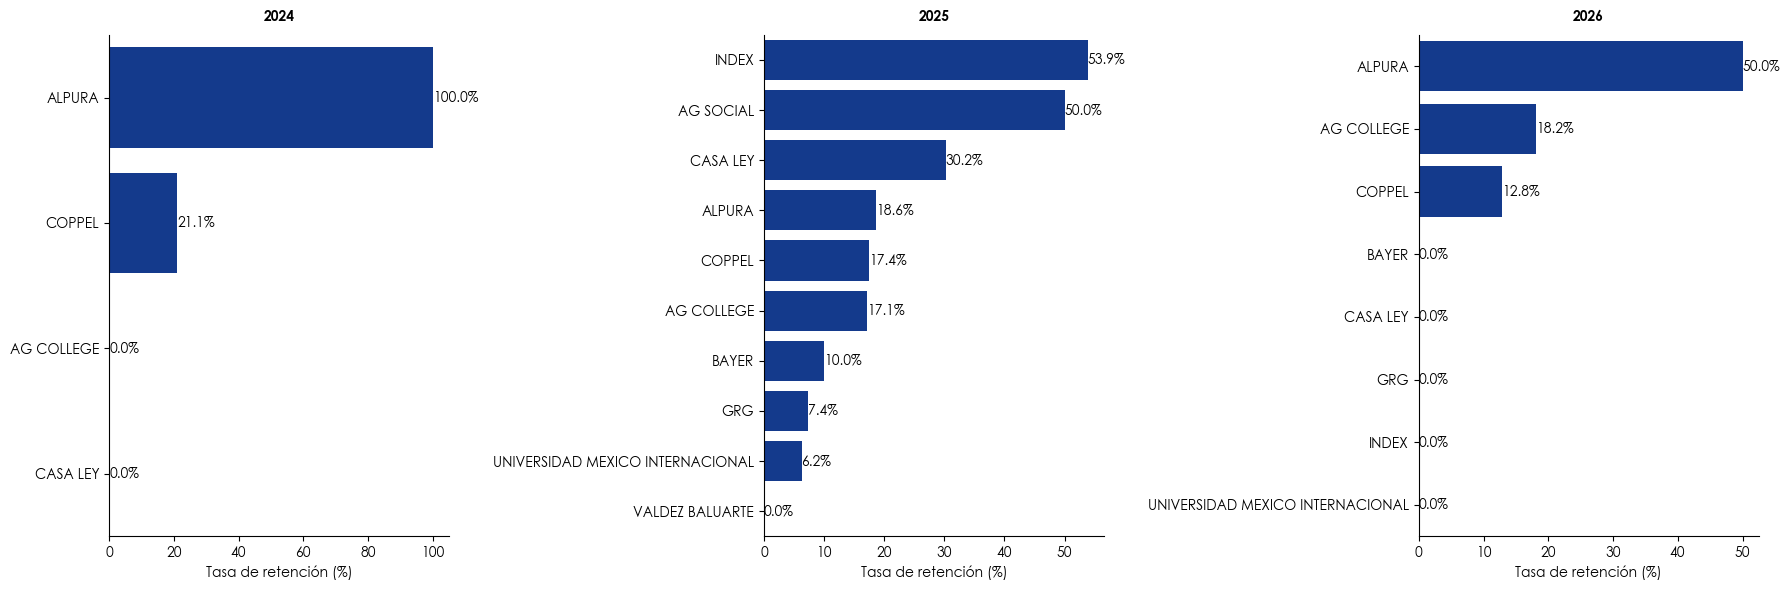

In [130]:
# Copia y ordena dentro de cada año
df_plot = retencion_corp.copy()


# Crear facets
g = sns.FacetGrid(
    df_plot,
    col="anio",
    sharex=False,   # puedes poner True si quieres mismo eje X
    sharey=False,
    height=6,
    aspect=1
)

g.map_dataframe(barplot_ordenado, x="tasa_retencion", y="corporacion", color="#0033A0")

# Títulos y estilo
g.set_titles("{col_name}", fontsize=20, fontweight="bold", color="black", pad=10)
g.set_axis_labels("Tasa de retención (%)", "")

for ax in g.axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [131]:
#Retención por programa
retencion_prog = (
    retencion
    .groupby(["anio", "programa"])
    .agg(
        total_registros=("id_alumno", "count"),
        total_retencion=("retencion", lambda x: (x == "SI").sum())
    )
    .reset_index()
)
retencion_prog["tasa_retencion"] = (
    retencion_prog["total_retencion"] /
    retencion_prog["total_registros"] * 100
).round(2)
retencion_prog


,anio,programa,total_registros,total_retencion,tasa_retencion
0,2024,IDS Coppel,10,1,10.00
1,2024,LDG AG LIC,2,0,0.00
2,2024,LDG Ley,1,0,0.00
3,2024,LEG COPPEL,18,4,22.22
4,2024,MDN Coppel,4,1,25.00
5,2024,PREPA COPPEL,6,2,33.33
6,2024,Prepa alpura,1,1,100.00
7,2025,ADMISIONES IDS COPPEL,1,0,0.00
8,2025,BACHILLERATO FALCO ELECTRONICS,1,0,0.00
9,2025,BACHILLERATO INDEX,9,6,66.67


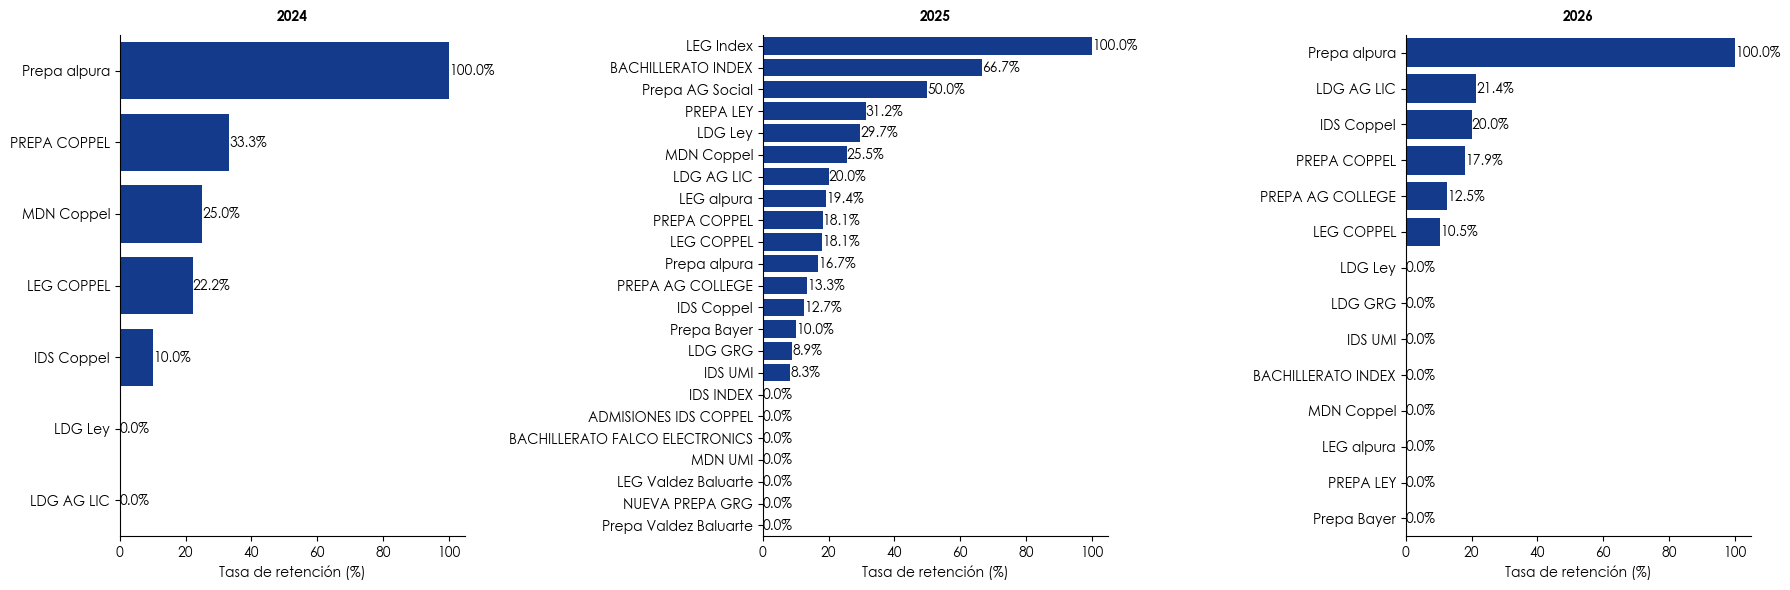

In [132]:
# Copia y ordena dentro de cada año
df_plot = retencion_prog.copy()


# Crear facets
g = sns.FacetGrid(
    df_plot,
    col="anio",
    sharex=False,   # puedes poner True si quieres mismo eje X
    sharey=False,
    height=6,
    aspect=1
)

g.map_dataframe(barplot_ordenado, x="tasa_retencion", y="programa", color="#0033A0")

# Títulos y estilo  
g.set_titles("{col_name}", fontsize=20, fontweight="bold", color="black", pad=10)
g.set_axis_labels("Tasa de retención (%)", "")

for ax in g.axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Abandono

In [40]:
##Calcular tasa de abandono por año
abandono_gral = (
    abandono
    .groupby("anio_referencia")
    .agg(
        total_registros=("id_alumno", "count"),
        total_bajas=("tuvo_baja_en_anio", "sum")
    )
    .reset_index()
)

# Calcular tasa de abandono
abandono_gral["tasa_abandono"] = (
    abandono_gral["total_bajas"] / abandono_gral["total_registros"]*100
)

abandono_gral

,anio_referencia,total_registros,total_bajas,tasa_abandono
0,2024,8585,1095,12.754805
1,2025,8048,1052,13.071571
2,2026,7734,212,2.741143


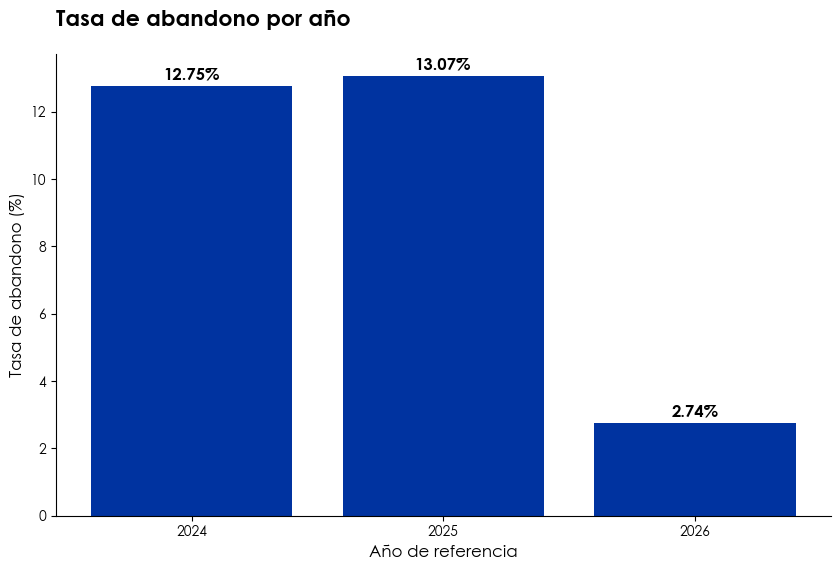

In [79]:
# Grafico de barras
plt.figure(figsize=(10, 6))
plt.bar(abandono_gral["anio_referencia"], abandono_gral["tasa_abandono"], color="#0033A0")
plt.title("Tasa de abandono por año", fontsize=16, pad=20, color="black", fontweight="bold", loc="left")
plt.xlabel("Año de referencia", fontsize=12)
plt.ylabel("Tasa de abandono (%)", fontsize=12)
#Añadir etiquetas de porcentaje encima de cada barra
for index, row in abandono_gral.iterrows():
    plt.text(row["anio_referencia"], row["tasa_abandono"] + 0.2,
              f"{row['tasa_abandono']:.2f}%", ha='center', fontsize=12, color="black", fontweight="bold")

plt.xticks(abandono_gral["anio_referencia"])
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()


In [42]:
# Abandono por corporación
abandono_corp = (
    abandono
    .groupby(["anio_referencia", "corporacion"])
    .agg(
        total_registros=("id_alumno", "count"),
        total_bajas=("tuvo_baja_en_anio", "sum")
    )
    .reset_index()
)
abandono_corp["tasa_abandono"] = (
    abandono_corp["total_bajas"] / abandono_corp["total_registros"]*
    100
)
abandono_corp

,anio_referencia,corporacion,total_registros,total_bajas,tasa_abandono
0,2024,ACADEMIA GLOBAL POR MÉXICO,10,2,20.000000
1,2024,AG COLLEGE,1002,33,3.293413
2,2024,AG SOCIAL,107,0,0.000000
3,2024,ALPURA,135,18,13.333333
4,2024,CASA LEY,1873,206,10.998398
5,2024,COPPEL,5196,828,15.935335
6,2024,GRG,2,0,0.000000
7,2024,INDEX,82,0,0.000000
8,2024,MABE,18,0,0.000000
9,2024,OPERADORA SI,3,0,0.000000


In [73]:
abandono.head()

,anio_referencia,id_alumno,idmoodle,id_plan_estudio,programa,id_corporacion,corporacion,estado_inicial,tuvo_baja_en_anio,fecha_baja
0,2024,89385,701,84,ACADEMIA GLOBAL POR MEXICO,13,ACADEMIA GLOBAL POR MÉXICO,1,1,2024-03-06 10:08:10
1,2024,89389,702,84,ACADEMIA GLOBAL POR MEXICO,13,ACADEMIA GLOBAL POR MÉXICO,1,0,NaT
2,2024,89392,703,84,ACADEMIA GLOBAL POR MEXICO,13,ACADEMIA GLOBAL POR MÉXICO,1,0,NaT
3,2024,89394,704,84,ACADEMIA GLOBAL POR MEXICO,13,ACADEMIA GLOBAL POR MÉXICO,1,0,NaT
4,2024,89398,705,84,ACADEMIA GLOBAL POR MEXICO,13,ACADEMIA GLOBAL POR MÉXICO,1,0,NaT


In [74]:
# Abandono por corporación
abandono_prog = (
    abandono
    .groupby(["anio_referencia", "programa"])
    .agg(
        total_registros=("id_alumno", "count"),
        total_bajas=("tuvo_baja_en_anio", "sum")
    )
    .reset_index()
)
abandono_prog["tasa_abandono"] = (
    abandono_prog["total_bajas"] / abandono_prog["total_registros"]*
    100
)
abandono_prog

,anio_referencia,programa,total_registros,total_bajas,tasa_abandono
0,2024,ACADEMIA GLOBAL POR MEXICO,10,2,20.000000
1,2024,BACHILLERATO INDEX,13,0,0.000000
2,2024,CERTIFICACIONES EJECUTIVAS,69,0,0.000000
3,2024,ESCUELAS DE UCL,1576,170,10.786802
4,2024,IDS COPPEL,458,115,25.109170
...,...,...,...,...,...
72,2026,PREPA COPPEL,1362,71,5.212922
73,2026,PREPA LEY,173,8,4.624277
74,2026,PREPA OXXO,16,0,0.000000
75,2026,PREPA SUMATE,18,18,100.000000


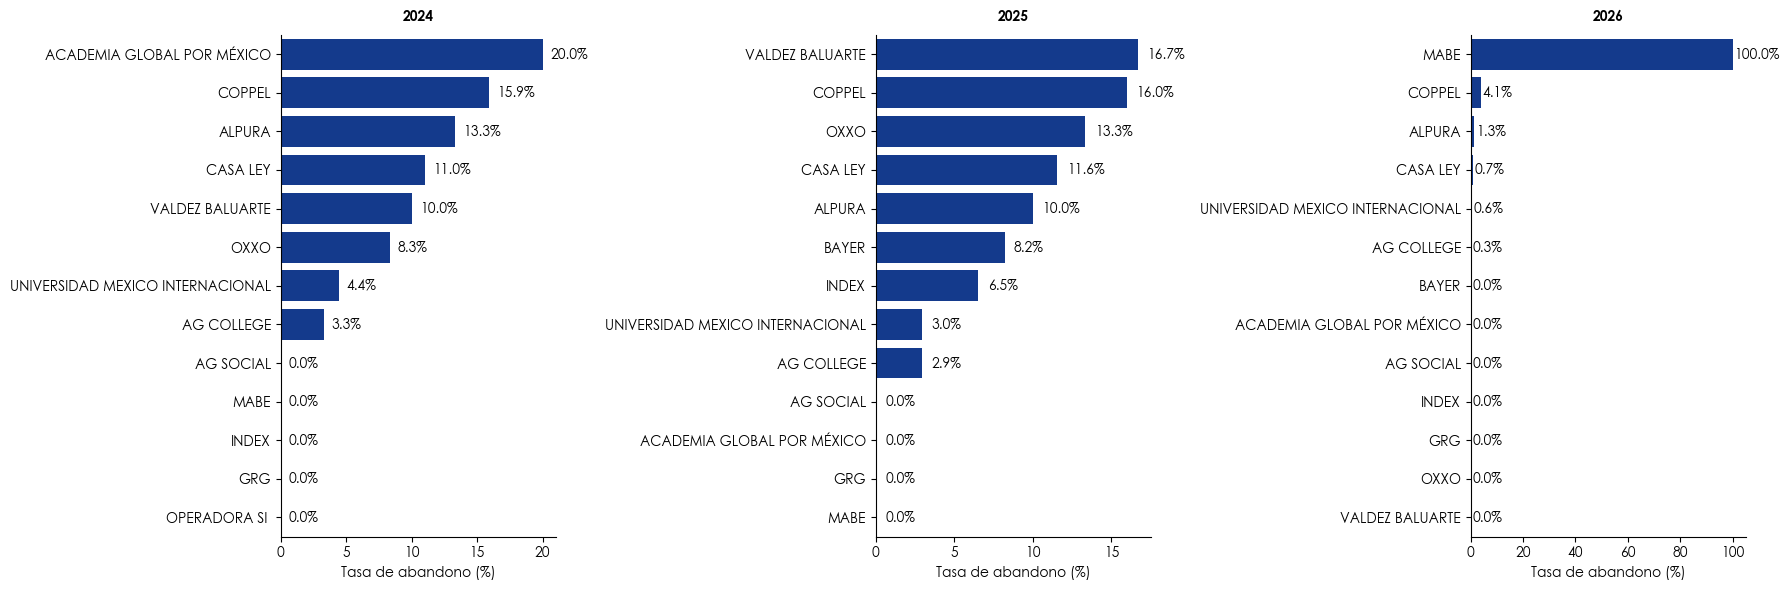

In [ ]:
# Copia y ordena dentro de cada año
df_plot = abandono_corp.copy()


# Crear facets
g = sns.FacetGrid(
    df_plot,
    col="anio_referencia",
    sharex=False,   # puedes poner True si quieres mismo eje X
    sharey=False,
    height=6,
    aspect=1
)

g.map_dataframe(barplot_ordenado)

# Títulos y estilo
g.set_titles("{col_name}", fontsize=20, fontweight="bold", color="black", pad=10)
g.set_axis_labels("Tasa de abandono (%)", "")

for ax in g.axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

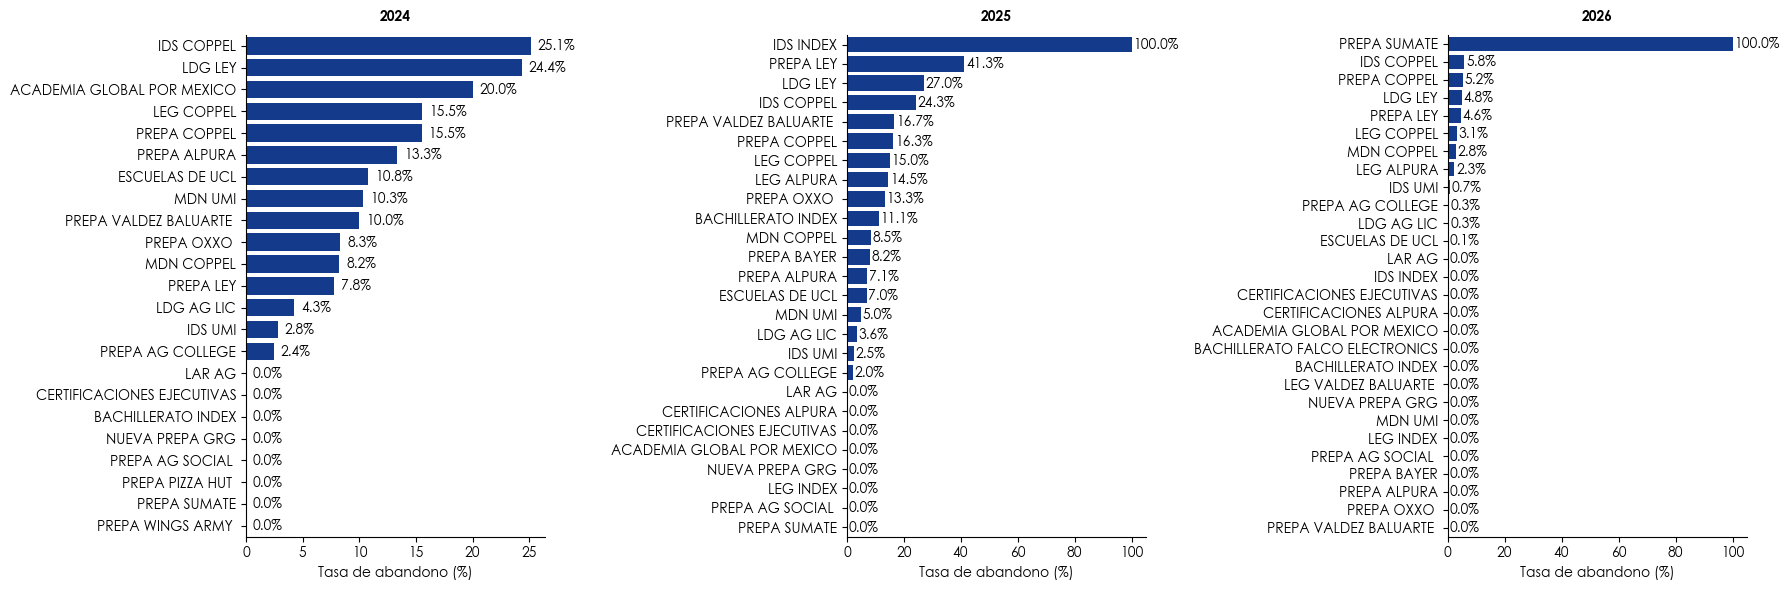

In [ ]:
# Copia y ordena dentro de cada año
df_plot = abandono_prog.copy()
# Crear facets
g = sns.FacetGrid(
    df_plot,
    col="anio_referencia",
    sharex=False,   # puedes poner True si quieres mismo eje X
    sharey=False,
    height=6,
    aspect=1
)

g.map_dataframe(barplot_ordenado)

# Títulos y estilo
g.set_titles("{col_name}", fontsize=20, fontweight="bold", color="black", pad=10)
g.set_axis_labels("Tasa de abandono (%)", "")

for ax in g.axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Abandono temprano

In [133]:
fragilidad

,id_alumno,id_plan_estudio,programa,id_corporacion,corporacion,anio_inscripcion,fecha_inscripcion,periodo_inscripcion,primer_carga,fecha_baja,fecha_solicitud_baja
0,91434,84,ACADEMIA GLOBAL POR MEXICO,13,ACADEMIA GLOBAL POR MÉXICO,2024,2024-05-15 12:51:38,2024-06-01,None,None,None
1,109163,84,ACADEMIA GLOBAL POR MEXICO,13,ACADEMIA GLOBAL POR MÉXICO,2024,2024-09-04 11:16:39,2024-09-01,None,2026-01-19,None
2,199275,84,ACADEMIA GLOBAL POR MEXICO,13,ACADEMIA GLOBAL POR MÉXICO,2025,2025-09-17 17:37:40,2025-10-01,2025-10-10 14:16:03,None,None
3,199276,84,ACADEMIA GLOBAL POR MEXICO,13,ACADEMIA GLOBAL POR MÉXICO,2025,2025-09-17 17:39:35,2025-10-01,2025-10-10 14:16:58,None,None
4,199277,84,ACADEMIA GLOBAL POR MEXICO,13,ACADEMIA GLOBAL POR MÉXICO,2025,2025-09-17 17:42:09,2025-10-01,2025-10-10 14:17:38,None,None
...,...,...,...,...,...,...,...,...,...,...,...
7339,194956,123,LEG VALDEZ BALUARTE,19,VALDEZ BALUARTE,2025,2025-05-30 13:37:57,2025-06-01,2025-06-04 10:19:47,2025-09-02,2025-06-24
7340,197140,123,LEG VALDEZ BALUARTE,19,VALDEZ BALUARTE,2025,2025-07-23 15:32:50,2025-08-01,2025-08-04 15:21:54,None,None
7341,197763,123,LEG VALDEZ BALUARTE,19,VALDEZ BALUARTE,2025,2025-08-04 10:57:23,2025-08-01,2025-08-05 19:18:25,None,None
7342,198810,123,LEG VALDEZ BALUARTE,19,VALDEZ BALUARTE,2025,2025-08-28 10:05:27,2025-09-01,2025-09-03 14:40:10,None,None


In [137]:
##Abandono general

# Asegurar que las fechas sean datetime
fragilidad["fecha_inscripcion"] = pd.to_datetime(fragilidad["fecha_inscripcion"])
fragilidad["fecha_baja"] = pd.to_datetime(fragilidad["fecha_baja"])

# Diferencia en días
fragilidad["dias_a_baja"] = (
    fragilidad["fecha_baja"] - fragilidad["fecha_inscripcion"]
).dt.days

# Variable abandono semana 4
fragilidad["abandono_sem4"] = np.where(
    (fragilidad["dias_a_baja"].notna()) & (fragilidad["dias_a_baja"] <= 28),
    1,
    0
)
fragilidad.head()

,id_alumno,id_plan_estudio,programa,id_corporacion,corporacion,anio_inscripcion,fecha_inscripcion,periodo_inscripcion,primer_carga,fecha_baja,fecha_solicitud_baja,dias_a_baja,abandono_sem4
0,91434,84,ACADEMIA GLOBAL POR MEXICO,13,ACADEMIA GLOBAL POR MÉXICO,2024,2024-05-15 12:51:38,2024-06-01,None,NaT,None,NaN,0
1,109163,84,ACADEMIA GLOBAL POR MEXICO,13,ACADEMIA GLOBAL POR MÉXICO,2024,2024-09-04 11:16:39,2024-09-01,None,2026-01-19,None,501.0,0
2,199275,84,ACADEMIA GLOBAL POR MEXICO,13,ACADEMIA GLOBAL POR MÉXICO,2025,2025-09-17 17:37:40,2025-10-01,2025-10-10 14:16:03,NaT,None,NaN,0
3,199276,84,ACADEMIA GLOBAL POR MEXICO,13,ACADEMIA GLOBAL POR MÉXICO,2025,2025-09-17 17:39:35,2025-10-01,2025-10-10 14:16:58,NaT,None,NaN,0
4,199277,84,ACADEMIA GLOBAL POR MEXICO,13,ACADEMIA GLOBAL POR MÉXICO,2025,2025-09-17 17:42:09,2025-10-01,2025-10-10 14:17:38,NaT,None,NaN,0


In [139]:
abandono_4_sem = (
    fragilidad
    .groupby("anio_inscripcion")
    .agg(
        total_registros=("id_alumno", "count"),
        total_abandono_sem4=("abandono_sem4", "sum")
    )
    .reset_index()
)   
# Calcular tasa de abandono
abandono_4_sem["tasa_abandono_sem4"] = (
    abandono_4_sem["total_abandono_sem4"] / abandono_4_sem["total_registros"]*100
).round(2)
abandono_4_sem


,anio_inscripcion,total_registros,total_abandono_sem4,tasa_abandono_sem4
0,2024,4012,46,1.15
1,2025,2911,43,1.48
2,2026,421,7,1.66


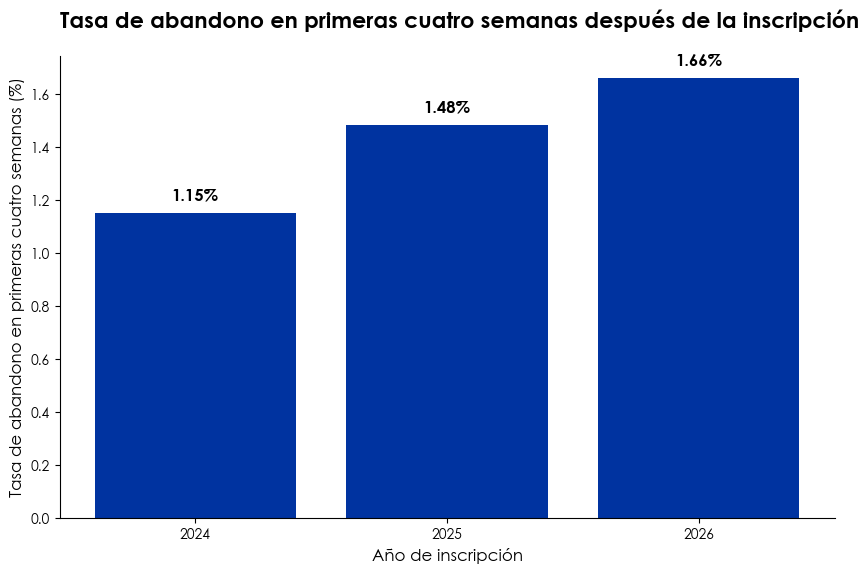

In [145]:
# GArfico de barras
plt.figure(figsize=(10, 6))
plt.bar(abandono_4_sem["anio_inscripcion"], abandono_4_sem["tasa_abandono_sem4"], color="#0033A0")
plt.title("Tasa de abandono en primeras cuatro semanas después de la inscripción", fontsize=16, pad=20, color="black", fontweight="bold", loc="left")
plt.xlabel("Año de inscripción", fontsize=12)
plt.ylabel("Tasa de abandono en primeras cuatro semanas (%)", fontsize=12)
#Añadir etiquetas de porcentaje encima de cada barra
for index, row in abandono_4_sem.iterrows():
    plt.text(row["anio_inscripcion"], row["tasa_abandono_sem4"] + 0.05,
              f"{row['tasa_abandono_sem4']:.2f}%", ha='center', fontsize=12, color="black", fontweight="bold")
plt.xticks(abandono_4_sem["anio_inscripcion"])
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()


In [146]:
## Abandono temprano por corporación

abandono_corp_4_sem = (
    fragilidad
    .groupby(["anio_inscripcion", "corporacion"])
    .agg(
        total_registros=("id_alumno", "count"),
        total_abandono_sem4=("abandono_sem4", "sum")
    )
    .reset_index()
)
abandono_corp_4_sem["tasa_abandono_sem4"] = (
    abandono_corp_4_sem["total_abandono_sem4"] / abandono_corp_4_sem["total_registros"]*
    100
).round(2)

abandono_corp_4_sem

,anio_inscripcion,corporacion,total_registros,total_abandono_sem4,tasa_abandono_sem4
0,2024,ACADEMIA GLOBAL POR MÉXICO,2,0,0.00
1,2024,AG COLLEGE,322,0,0.00
2,2024,ALPURA,279,1,0.36
3,2024,BAYER,87,0,0.00
4,2024,CASA LEY,251,2,0.80
5,2024,COPPEL,2983,42,1.41
6,2024,INDEX,22,1,4.55
7,2024,OXXO,12,0,0.00
8,2024,UNIVERSIDAD MEXICO INTERNACIONAL,52,0,0.00
9,2024,VALDEZ BALUARTE,2,0,0.00


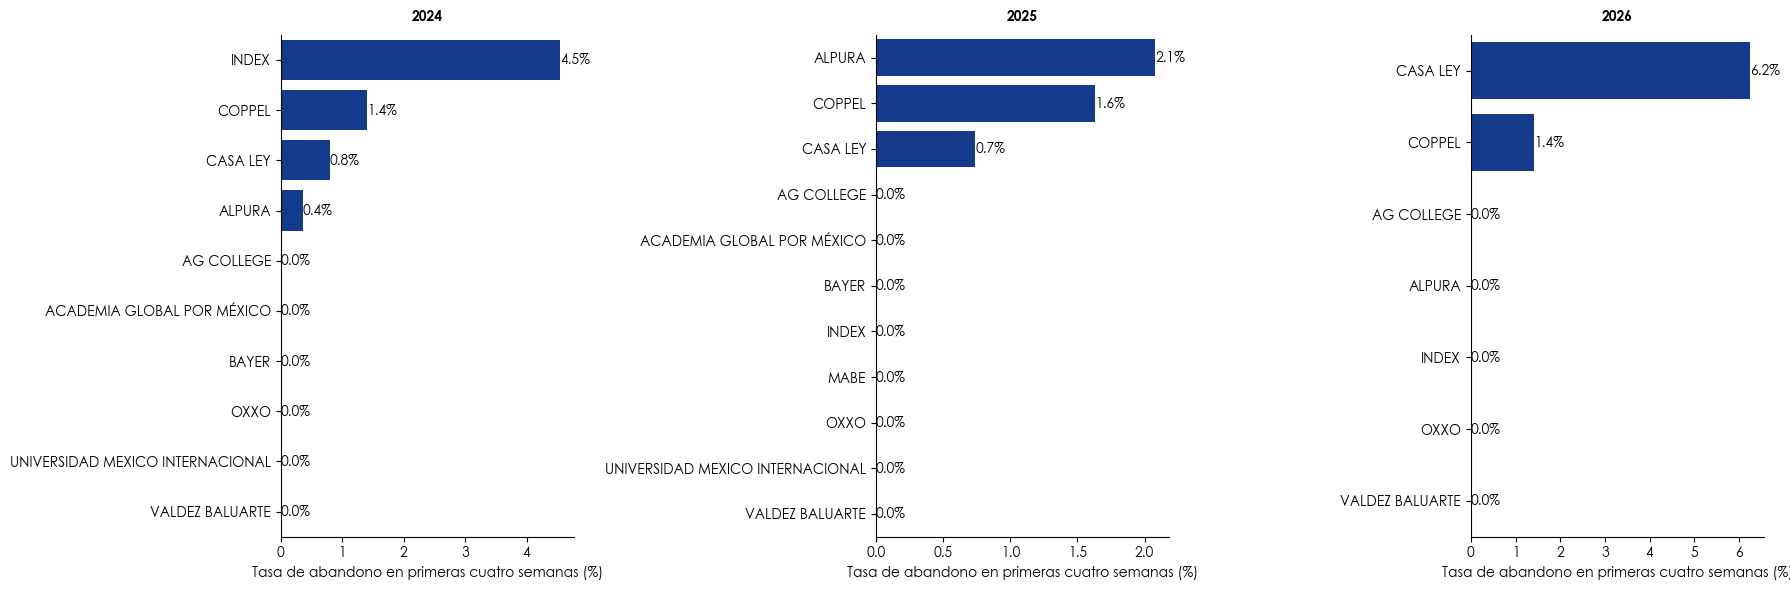

In [148]:
# Grafico de barras
# Copia y ordena dentro de cada año
df_plot = abandono_corp_4_sem.copy()


# Crear facets
g = sns.FacetGrid(
    df_plot,
    col="anio_inscripcion",
    sharex=False,   # puedes poner True si quieres mismo eje X
    sharey=False,
    height=6,
    aspect=1
)

g.map_dataframe(barplot_ordenado, x="tasa_abandono_sem4", y="corporacion", color="#0033A0")

# Títulos y estilo  
g.set_titles("{col_name}", fontsize=20, fontweight="bold", color="black", pad=10)
g.set_axis_labels("Tasa de abandono en primeras cuatro semanas (%)", "")

for ax in g.axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [149]:
# Abandono temprano por programa

abandono_prog_4_sem = (
    fragilidad
    .groupby(["anio_inscripcion", "programa"])
    .agg(
        total_registros=("id_alumno", "count"),
        total_abandono_sem4=("abandono_sem4", "sum")
    )
    .reset_index()
)
abandono_prog_4_sem["tasa_abandono_sem4"] = (
    abandono_prog_4_sem["total_abandono_sem4"] / abandono_prog_4_sem["total_registros"]*
    100
).round(2)
abandono_prog_4_sem

,anio_inscripcion,programa,total_registros,total_abandono_sem4,tasa_abandono_sem4
0,2024,ACADEMIA GLOBAL POR MEXICO,2,0,0.00
1,2024,BACHILLERATO INDEX,13,1,7.69
2,2024,IDS COPPEL,334,5,1.50
3,2024,IDS INDEX,6,0,0.00
4,2024,IDS UMI,45,0,0.00
5,2024,INGENIERÍA INDUSTRIAL AG COLLEGE,1,0,0.00
6,2024,LDG AG LIC,140,0,0.00
7,2024,LDG LEY,110,2,1.82
8,2024,LEG ALPURA,186,1,0.54
9,2024,LEG COPPEL,1335,18,1.35


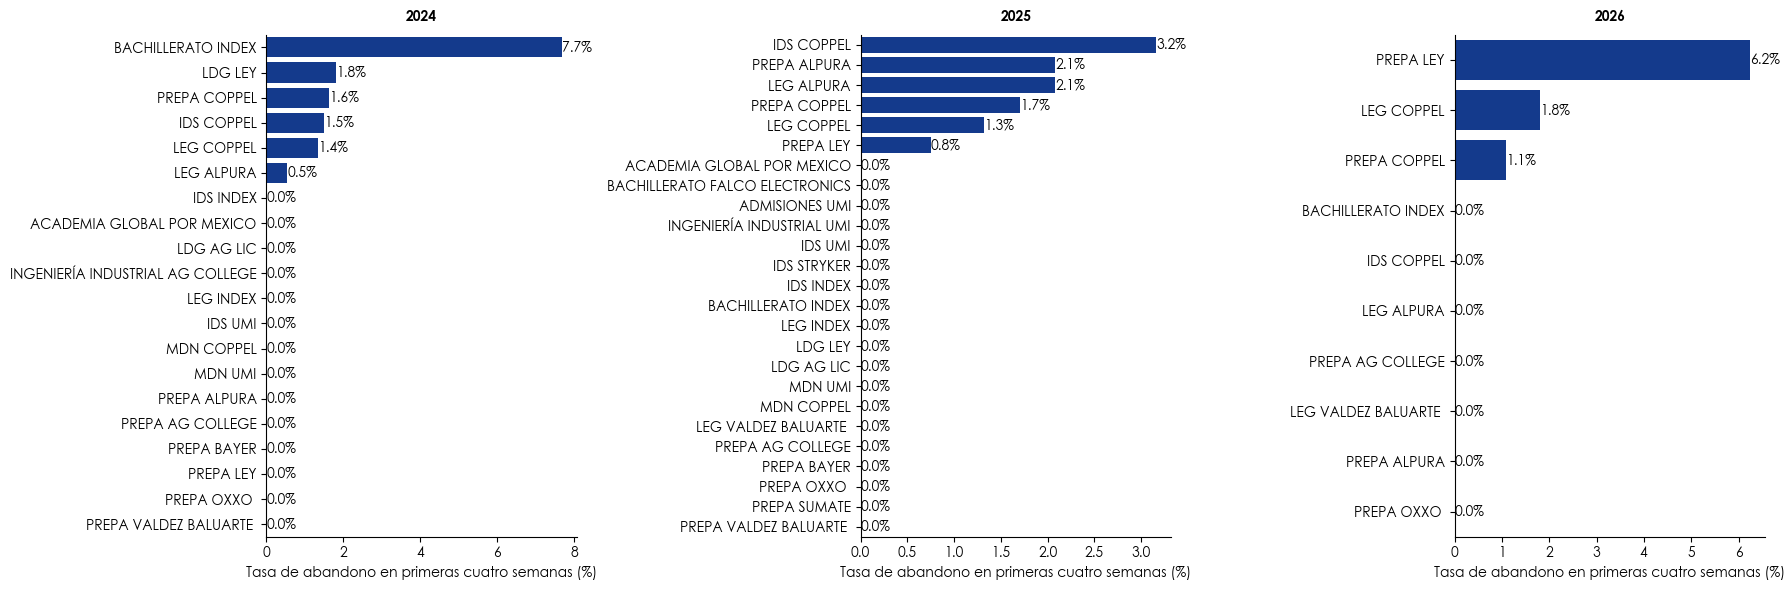

2026-02-23 02:30:07,041| ERROR   | Socket exception: Se ha forzado la interrupción de una conexión existente por el host remoto (10054)
2026-02-23 02:30:08,346| ERROR   | Socket exception: Se ha forzado la interrupción de una conexión existente por el host remoto (10054)
2026-02-23 02:30:08,347| ERROR   | Socket exception: Se ha forzado la interrupción de una conexión existente por el host remoto (10054)
2026-02-23 02:30:09,127| ERROR   | Socket exception: Se ha forzado la interrupción de una conexión existente por el host remoto (10054)
2026-02-23 02:30:09,136| ERROR   | Socket exception: Se ha forzado la interrupción de una conexión existente por el host remoto (10054)


In [ ]:
# Grafico de barras
# Copia y ordena dentro de cada año
df_plot = abandono_prog_4_sem.copy()


# Crear facets
g = sns.FacetGrid(
    df_plot,
    col="anio_inscripcion",
    sharex=False,   # puedes poner True si quieres mismo eje X
    sharey=False,
    height=6,
    aspect=1
)

g.map_dataframe(barplot_ordenado, x="tasa_abandono_sem4", y="programa", color="#0033A0")

# Títulos y estilo  
g.set_titles("{col_name}", fontsize=20, fontweight="bold", color="black", pad=10)
g.set_axis_labels("Tasa de abandono en primeras cuatro semanas (%)", "")

for ax in g.axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()